# Has the rate of great earthquakes really increased?

Between December 2004 and March 2011 the planet produced an extraordinary run of giant
earthquakes — **Sumatra–Andaman (M9.1, 2004)**, **Maule, Chile (M8.8, 2010)** and
**Tōhoku, Japan (M9.1, 2011)** — three of the six largest events ever instrumentally
recorded, within seven years. This naturally raised an alarming question: *is the Earth
entering a more seismically active phase, or is this cluster just bad luck?* Shearer &
Stark (PNAS 2012) and Michael (GRL 2011) argued statistically for "bad luck." Here we
give an independent answer with *bayesloop*, by letting the **annual rate of great
earthquakes vary freely in time** and asking whether the data actually demand any such
variation.

This is the mirror image of the measles example. There the evidence overwhelmingly
favoured a *changing* parameter; here the right answer turns out to be that the
parameter is *constant* — and a good method must be able to say so. Along the way we
exercise a representative slice of the toolbox: a `Poisson` observation model under
`Study` (static), `HyperStudy` (marginalising a random-walk step size), `RegimeSwitch`,
and a `ChangepointStudy` scan — all sharing one observation model so their **marginal
evidences are directly comparable** and complexity is penalised automatically.

In [1]:
%matplotlib inline
import io
import urllib.request

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import bayesloop as bl

try:
    import seaborn as sns
    sns.set_style("whitegrid")
except ImportError:
    plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 110, "font.size": 10.5, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.edgecolor": "#444444", "grid.color": "#d9d9d9",
})
C = {"data": "#8a8a8a", "accent": "#c1272d", "accent2": "#0b6e99",
     "green": "#2e7d32", "amber": "#e8a33d", "muted": "#8a8a8a",
     "band": "#c1272d", "band2": "#0b6e99"}


def posterior_band(S, name, lo=0.05, hi=0.95):
    """Posterior mean and an equal-tailed credible band for a time-varying parameter."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mean = (p * x[None, :]).sum(axis=1)
    cdf = np.cumsum(p, axis=1)
    low = np.array([np.interp(lo, cdf[t], x) for t in range(p.shape[0])])
    high = np.array([np.interp(hi, cdf[t], x) for t in range(p.shape[0])])
    return mean, low, high


def prob_in(S, name, lo=None, hi=None):
    """Posterior probability the parameter lies in (lo, hi] at each time step."""
    x, p = S.get_parameter_distributions(name, density=False)
    p = np.asarray(p, dtype=float)
    p /= p.sum(axis=1, keepdims=True)
    mask = np.ones_like(x, dtype=bool)
    if lo is not None:
        mask &= x > lo
    if hi is not None:
        mask &= x <= hi
    return p[:, mask].sum(axis=1)

## The data

We pull the catalogue **live** from the
[USGS ComCat / FDSN event service](https://earthquake.usgs.gov/fdsnws/event/1/). The
service caps the number of events per request, so we page the query **decade by
decade** (1900–2025), asking for every M ≥ 7 event and concatenating the CSV chunks.
A short pause between requests keeps us polite to the public endpoint.

The catalogue is essentially **complete for M ≥ 8** ("great" earthquakes) back to 1900,
so that is the series we analyse — binned into annual counts (0–4 events per year) and
modelled directly with a Poisson observation model.

> ⚠️ We deliberately analyse **M ≥ 8 rather than M ≥ 7**. Completeness for M ≥ 7 is
> *not* uniform over the century: the apparent rise in recent decades is largely a
> detection/catalogue artefact (denser seismometer networks). M ≥ 8 avoids that
> confound.

In [2]:
UA = "Mozilla/5.0 (bayesloop docs; research; contact chris@karamata-capital.com)"


def fetch_quakes():
    """Page the USGS FDSN event service by decade and return a concatenated DataFrame."""
    import time
    chunks, header, start = [], None, 1900
    while start <= 2025:
        end = min(start + 9, 2025)
        url = (
            "https://earthquake.usgs.gov/fdsnws/event/1/query?format=csv"
            f"&starttime={start}-01-01&endtime={end}-12-31"
            "&minmagnitude=7.0&orderby=time-asc"
        )
        req = urllib.request.Request(url, headers={"User-Agent": UA})
        txt = (urllib.request.urlopen(req, timeout=120)
               .read().decode("utf-8", "replace").strip().splitlines())
        if txt:
            if header is None:
                header = txt[0]
                chunks.append(header)
            chunks.extend(txt[1:])
            print(f"  quakes {start}-{end}: {len(txt) - 1} events")
        start = end + 1
        time.sleep(1.0)
    return pd.read_csv(io.StringIO("\n".join(chunks)))


df = fetch_quakes()
df["year"] = pd.to_datetime(df["time"], format="ISO8601", utc=True).dt.year
df = df[df["year"] <= 2025]
years = np.arange(1900, 2026)

THR = 8.0
great = df[df["mag"] >= THR]
counts = great.groupby("year").size().reindex(years, fill_value=0).values.astype(float)
mean_rate = counts.mean()
disp = counts.var(ddof=1) / counts.mean()      # index of dispersion (==1 for Poisson)
print(f"\nM>={THR}: {int(counts.sum())} events, mean {mean_rate:.3f}/yr, "
      f"dispersion index (var/mean) = {disp:.2f}  (Poisson -> 1.0)")

# giant (M>=8.5) clusters
giant = df[df["mag"] >= 8.5]
gc = giant.groupby("year").size()
clust_50s = int(gc.loc[(gc.index >= 1950) & (gc.index <= 1965)].sum())
clust_00s = int(gc.loc[(gc.index >= 2004) & (gc.index <= 2012)].sum())
print(f"M>=8.5 giants: {len(giant)} total; 1950-1965 cluster = {clust_50s}, "
      f"2004-2012 cluster = {clust_00s}")

  quakes 1900-1909: 148 events


  quakes 1910-1919: 129 events


  quakes 1920-1929: 107 events


  quakes 1930-1939: 115 events


  quakes 1940-1949: 119 events


...

  quakes 1990-1999: 154 events


  quakes 2000-2009: 143 events


  quakes 2010-2019: 160 events


  quakes 2020-2025: 84 events



M>=8.0: 100 events, mean 0.794/yr, dispersion index (var/mean) = 0.97  (Poisson -> 1.0)
M>=8.5 giants: 17 total; 1950-1965 cluster = 7, 2004-2012 cluster = 5


**A textbook-clean Poisson signature already.** The annual counts have an **index of
dispersion (variance / mean) ≈ 1** — exactly what a homogeneous Poisson process
predicts. By this classical diagnostic alone the counts are already indistinguishable
from constant-rate randomness. Note too that the **1950s–60s cluster of M ≥ 8.5 giants
is at least as large as the celebrated 2004–2012 one** — any "recent increase"
narrative has to explain away an earlier burst that was just as big (it included the
1960 Chile M9.5, the largest earthquake ever recorded).

## Model comparison: constant vs. time-varying Poisson rate

The observation model is a single shared `bl.om.Poisson('rate', …)`. We pit three
hypotheses about how the rate behaves over 126 years against each other, and add a
change-point scan afterwards:

| Model | Transition | Question |
|---|---|---|
| Constant rate | `tm.Static()` | homogeneous Poisson process (null) |
| Gradually varying | `tm.GaussianRandomWalk` (HyperStudy over step size σ) | does the rate drift? |
| Regime-switching | `tm.RegimeSwitch` | does the rate jump between levels? |

Because all three share the identical Poisson observation model and data, their
**log₁₀ marginal evidences are directly comparable**, and the marginalisation
automatically penalises the extra flexibility of the time-varying models.

In [3]:
def poisson():
    return bl.om.Poisson("rate", bl.oint(0, 5, 600))

# M1 — Static (constant rate): the homogeneous-Poisson null.
S0 = bl.Study()
S0.load_data(counts, timestamps=years)
S0.set(poisson(), bl.tm.Static())
S0.fit(silent=True)

# M2 — Gradually varying rate (HyperStudy marginalises the random-walk step size).
S2 = bl.HyperStudy()
S2.load_data(counts, timestamps=years)
S2.set(poisson(), bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 0.5, 40), target="rate"))
S2.fit(silent=True)
sig_x, sig_p = S2.get_hyper_parameter_distribution("sigma")
rate_mean, rate_lo, rate_hi = posterior_band(S2, "rate")

# M3 — Regime-switching rate (allows rare abrupt jumps).
S3 = bl.Study()
S3.load_data(counts, timestamps=years)
S3.set(poisson(), bl.tm.RegimeSwitch("log10p_min", -3))
S3.fit(silent=True)

evid = {
    "Constant rate (Poisson)": float(S0.log10_evidence),
    "Gradually varying rate": float(S2.log10_evidence),
    "Regime-switching rate": float(S3.log10_evidence),
}
best = max(evid, key=evid.get)
print("\nMODEL EVIDENCE (log10):")
for k, v in evid.items():
    print(f"  {k:26s} {v:9.3f}")
print(f"  best: {best}   (Delta vs constant: "
      f"{evid['Gradually varying rate']-evid['Constant rate (Poisson)']:+.2f} for varying)")

+ Created new study.
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


+ Created new study.
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Regime-switching model. Hyper-Parameter(s): ['log10p_min']

MODEL EVIDENCE (log10):
  Constant rate (Poisson)      -65.092
  Gradually varying rate       -65.801
  Regime-switching rate        -65.195
  best: Constant rate (Poisson)   (Delta vs constant: -0.71 for varying)


**The evidence favours the constant rate.** The static homogeneous-Poisson model wins
outright; the flexible random-walk model is the worst of the three, paying an Occam
penalty for freedom it does not need (≈ 10⁰·⁷ ≈ 5× less probable). This is the headline:
a method that can *only* ever find time-variation would be dangerous, but *bayesloop*'s
marginal-likelihood model selection returns a principled **null** result.

We can make the statement even sharper by looking at the posterior of the random-walk
step size σ (the magnitude of year-to-year rate change), and by checking the verdict is
not an artefact of the prior on the rate.

In [4]:
# Posterior mass on "essentially no variation" (sigma small)
p_sigma_small = float(np.sum(sig_p[sig_x <= 0.05]))
print(f"P(sigma <= 0.05) = {p_sigma_small:.2f};  sigma posterior mode = "
      f"{sig_x[np.argmax(sig_p)]:.3f}  (0 -> no temporal variation)")

# Prior sensitivity: the constant-rate preference should not hinge on the default (Jeffreys)
# prior on the rate.  Re-run static vs gradual under a FLAT prior and confirm the verdict holds.
def pois_flat():
    return bl.om.Poisson("rate", bl.oint(0, 5, 600), prior=lambda rate: np.ones_like(rate))
S0f = bl.Study(); S0f.load_data(counts, timestamps=years); S0f.set(pois_flat(), bl.tm.Static()); S0f.fit(silent=True)
S2f = bl.HyperStudy(); S2f.load_data(counts, timestamps=years)
S2f.set(pois_flat(), bl.tm.GaussianRandomWalk("sigma", bl.cint(0, 0.5, 40), target="rate")); S2f.fit(silent=True)
print(f"Prior sensitivity (static - gradual, log10): Jeffreys "
      f"{S0.log10_evidence - S2.log10_evidence:+.2f}, flat "
      f"{S0f.log10_evidence - S2f.log10_evidence:+.2f}  (both favour constant)")

P(sigma <= 0.05) = 0.42;  sigma posterior mode = 0.000  (0 -> no temporal variation)
+ Created new study.
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Static/constant parameter values. Hyper-Parameter(s): []
+ Created new study.
  --> Hyper-study
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Gaussian random walk. Hyper-Parameter(s): ['sigma']


Prior sensitivity (static - gradual, log10): Jeffreys +0.71, flat +0.79  (both favour constant)


The σ posterior **peaks at exactly 0 and decays monotonically** — the data prefer *no*
temporal variation at all, the strongest Bayesian statement of constancy one can make.
And the constant model stays ahead by essentially the same margin whether we use the
default Jeffreys prior on the rate or a flat one, so the verdict is **not** an artefact
of the prior.

## A change-point scan around 2004

One last check: if we *force* a single rate change-point and let `ChangepointStudy`
scan every possible year, does the posterior concentrate near 2004 (the Sumatra event)?
A genuine break would show up as a sharp peak.

In [5]:
Scp = bl.ChangepointStudy()
Scp.load_data(counts, timestamps=years)
Scp.set(poisson(), bl.tm.ChangePoint("t_change", "all"))
Scp.fit(silent=True)
cp_x, cp_p = Scp.get_hyper_parameter_distribution("t_change")
# how concentrated is the change-point posterior? (a real break -> sharp peak)
cp_mode = float(cp_x[np.argmax(cp_p)])
cp_modeprob = float(cp_p.max())
print(f"Change-point study: evidence {Scp.log10_evidence:.2f}; "
      f"posterior mode {cp_mode:.0f} carries only {cp_modeprob:.2f} probability "
      f"(diffuse -> no compelling single break).")

# How elevated was the rate during the 2004-2011 window vs long-term?
idx = (years >= 2004) & (years <= 2011)
print(f"Inferred mean rate 2004-2011 = {rate_mean[idx].mean():.2f}/yr "
      f"vs long-term {mean_rate:.2f}/yr")

+ Created new study.
  --> Hyper-study
  --> Change-point analysis
+ Successfully imported array.
+ Observation model: Poisson. Parameter(s): ['rate']
+ Transition model: Change-point. Hyper-Parameter(s): ['t_change']
+ Detected 1 change-point(s) in transition model: ['t_change']
+ Set hyper-prior(s): ['uniform']


Change-point study: evidence -67.76; posterior mode 1902 carries only 0.07 probability (diffuse -> no compelling single break).
Inferred mean rate 2004-2011 = 1.03/yr vs long-term 0.79/yr


The change-point posterior is **diffuse** — its modal year carries only a few percent
of the probability and there is no concentration near 2004. There is simply no break to
find. Even the most flexible inferred rate barely lifts during 2004–2011 (to ≈ 1/yr,
against a ≈ 0.8/yr long-term mean), and its credible band still comfortably contains the
constant rate. Time now to visualise all of this.

### Figure 1 — the inferred rate never escapes the constant

Annual M ≥ 8 counts (bars), the most flexible inferred rate with its 90% credible band
(red), and the long-term mean (dashed). The two highlighted windows are the 1952–65 and
2004–12 clusters of M ≥ 8.5 giants.

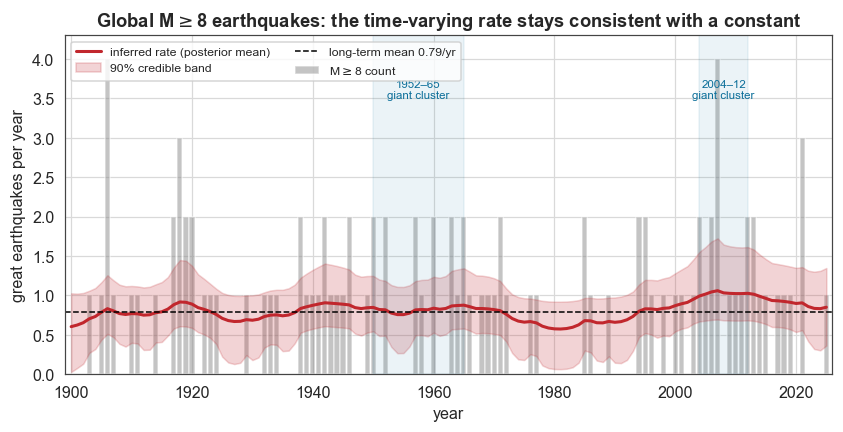

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.0))
ax.bar(years, counts, width=0.85, color=C["muted"], alpha=0.5, label=f"M$\\geq${THR:.0f} count")
ax.plot(years, rate_mean, color=C["accent"], lw=2.0, label="inferred rate (posterior mean)")
ax.fill_between(years, rate_lo, rate_hi, color=C["band"], alpha=0.20, label="90% credible band")
ax.axhline(mean_rate, color="k", ls="--", lw=1, label=f"long-term mean {mean_rate:.2f}/yr")
for x0, x1, lab in [(1950, 1965, "1952–65\ngiant cluster"), (2004, 2012, "2004–12\ngiant cluster")]:
    ax.axvspan(x0, x1, color=C["accent2"], alpha=0.08)
    ax.text((x0 + x1) / 2, 3.5, lab, ha="center", fontsize=7.5, color=C["accent2"])
ax.set_xlim(1899, 2026)
ax.set_ylim(0, 4.3)
ax.set_ylabel("great earthquakes per year")
ax.set_xlabel("year")
ax.set_title("Global M$\\geq$8 earthquakes: the time-varying rate stays consistent with a constant")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.show()

### Figure 2 — model evidence and the σ posterior

Left: log₁₀ evidence of each model relative to the worst. Right: the posterior for the
random-walk step size σ, which pins at zero.

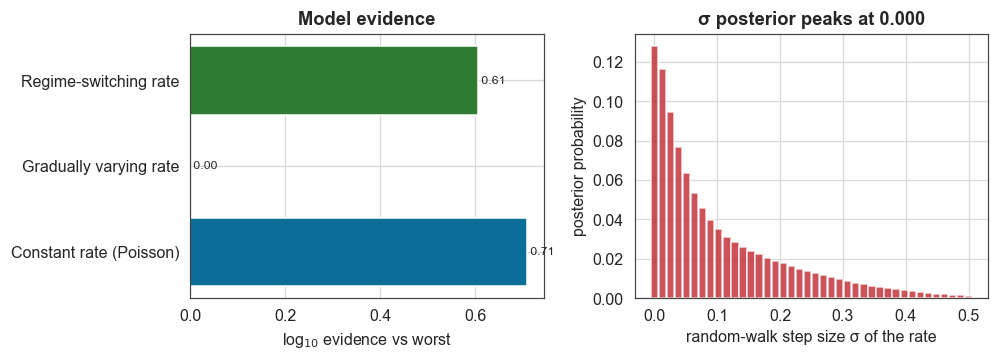

In [7]:
fig, (axa, axb) = plt.subplots(1, 2, figsize=(9.2, 3.4))
labels = list(evid.keys())
vals = np.array([evid[k] for k in labels]) - min(evid.values())
axa.barh(labels, vals, color=[C["accent2"], C["accent"], C["green"]])
axa.set_xlabel(r"log$_{10}$ evidence vs worst")
axa.set_title("Model evidence")
for i, v in enumerate(vals):
    axa.text(v, i, f" {v:.2f}", va="center", fontsize=8)
axb.bar(sig_x, sig_p, width=(sig_x[1] - sig_x[0]) * 0.9, color=C["accent"], alpha=0.8)
axb.set_xlabel("random-walk step size σ of the rate")
axb.set_ylabel("posterior probability")
axb.set_title(f"σ posterior peaks at {sig_x[np.argmax(sig_p)]:.3f}")
plt.tight_layout()
plt.show()

### Figure 3 — the change-point posterior is diffuse

Forcing a single break anywhere in the century, the posterior spreads across the whole
record with no peak at 2004.

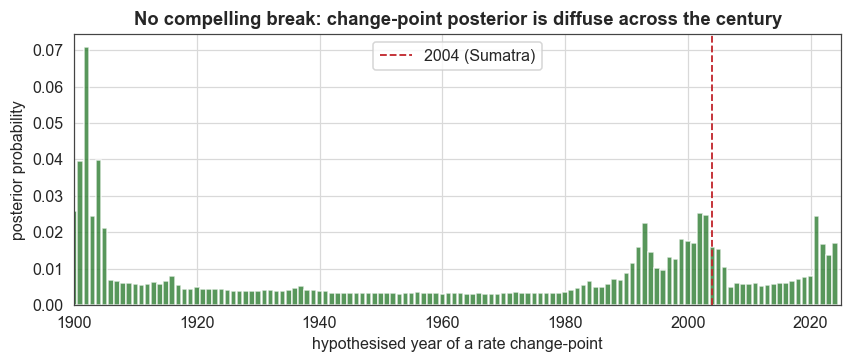

In [8]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(cp_x, cp_p, width=0.9, color=C["green"], alpha=0.8)
ax.axvline(2004, color=C["accent"], ls="--", lw=1.2, label="2004 (Sumatra)")
ax.set_xlim(1900, 2025)
ax.set_xlabel("hypothesised year of a rate change-point")
ax.set_ylabel("posterior probability")
ax.set_title("No compelling break: change-point posterior is diffuse across the century")
ax.legend()
plt.show()

## What this example showed

*bayesloop* independently reproduces the headline of Shearer & Stark (2012): **the
global rate of great earthquakes shows no statistically significant increase.** On this
single dataset we used the framework to:

- **return a principled null result** — with one shared Poisson observation model, the
  marginal-likelihood model selection prefers the **constant** rate over both a gradual
  random walk and a regime switch, and the σ posterior is pinned at zero;
- **stress-test that verdict** — it survives swapping the Jeffreys prior on the rate for
  a flat one, and a `ChangepointStudy` scan finds **no** concentrated break near 2004;
- **exercise a representative toolbox** — `Study`, `HyperStudy`, `ChangepointStudy`, a
  `Poisson` observation model, and `Static` / `GaussianRandomWalk` / `RegimeSwitch` /
  `ChangePoint` transitions, all directly comparable through their evidence.

It pairs naturally with the measles example: the *same* Poisson machinery, the
*opposite* conclusion — a clean illustration that the **evidence**, not the modeller,
decides. The 2004–2011 cluster of giant earthquakes (and the comparably-sized 1952–1965
one before it) is exactly what a constant ≈ 0.8/year Poisson process produces from time
to time.